# OMU Problem Set 1: Simulating charged particle orbits in magnetic fields

### To run a cell, click the cell and press shift+enter

# Section 0: Preamble

In [377]:
# Import the necessary Python packages

%matplotlib notebook
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [294]:
# Set default formatting parameters for plots

mpl.rcParams.update({
    "figure.figsize": (5,5),

    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,

    "axes.grid": True,
    "grid.alpha": 0.5,
})

In [3]:
# Define the Boris Push: given a particle's current position (x), velocity (v), charge (q), and mass (m), 
# in addition to the electric (E) and magnetic (B) fields at the particle's position, move the particle to 
# its new position a time-step dt into the future. Units are arbitrary (and c=1).

def boris_push(x, v, q, m, E, B, dt):

    # Half acceleration due to E
    v_minus = v + (q * E / m) * (dt / 2)

    # Magnetic rotation
    t = (q * B / m) * (dt / 2)
    t_mag2 = np.dot(t, t)

    s = 2 * t / (1 + t_mag2)

    v_prime = v_minus + np.cross(v_minus, t)
    v_plus  = v_minus + np.cross(v_prime, s)

    # Second half acceleration due to E
    v_new = v_plus + (q * E / m) * (dt / 2)

    # Position update
    x_new = x + v_new * dt

    return x_new, v_new

# Section 1: Particle motion in a static, uniform magnetic field

In [291]:
# Run the simulation

steps = 1000   # number of time steps over which to advance the particle
dt = 0.01      # size of a single time step, in arbitrary units

pos_uniform = np.zeros((steps, 3))    # initialize an array to track particle positions
vels_uniform = np.zeros((steps, 3))   # initialize an array to track particle velocities

q = 1.0                                      # particle's charge, in arbitrary units (change this)
m = 1.0                                      # particle's mass, in arbitrary units (change this)
pos_uniform[0] = np.array([-1.0, 0.0, 0.0])  # particle's initial position, [x, y, z]  
vels_uniform[0] = np.array([0.0, 1.0, 0.1])  # particle's initial velocity, [vx, vy, vz]  (change this)

E = np.array([0.0, 0.0, 0.0])    # static electric field, set to 0
B = np.array([0.0, 0.0, 1.0])    # static magnetic field in z-direction (only change z-component)

# trace out the particle's trajectory and save position and velocity at each time step
for i in range(1, steps):
    newpos, newvel = boris_push(pos_uniform[i-1], vels_uniform[i-1], q, m, E, B, dt)
    pos_uniform[i] = newpos
    vels_uniform[i] = newvel

<IPython.core.display.Javascript object>


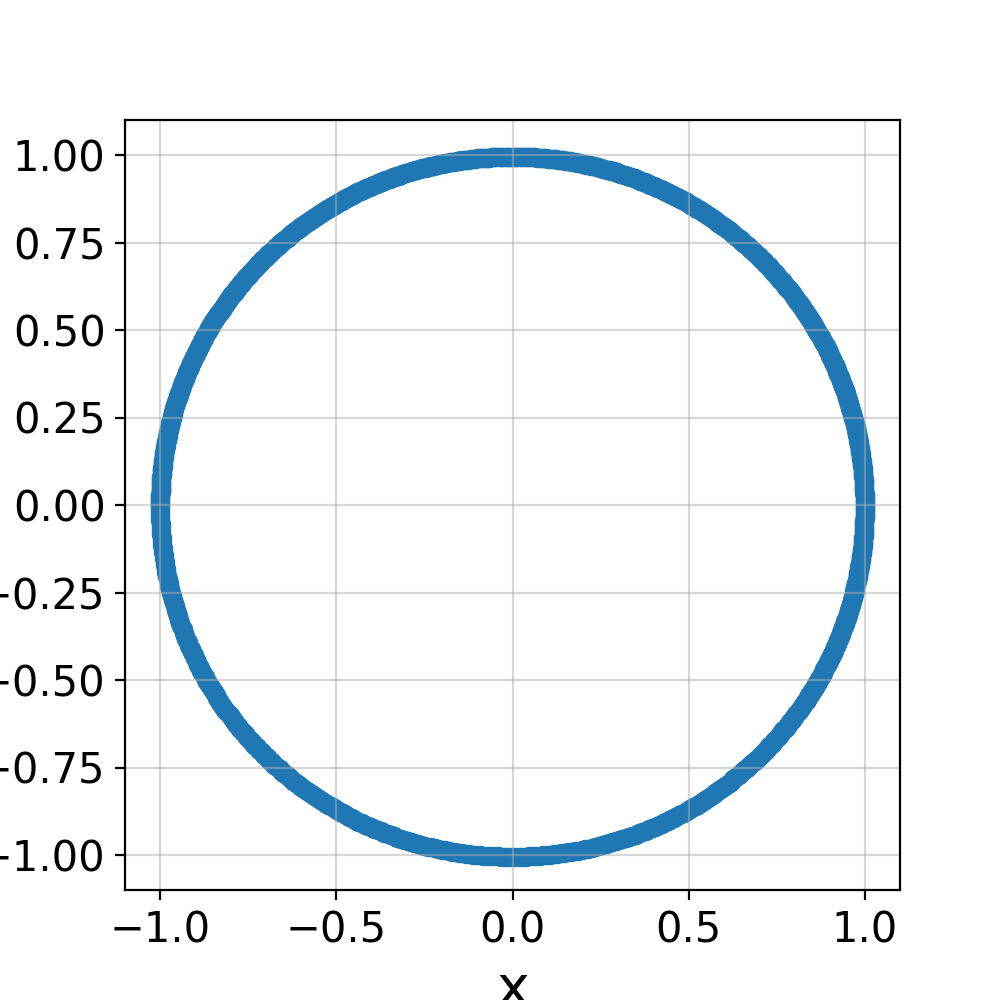

Text(0, 0.5, 'y')

In [292]:
# Plot the trajectory
fig = plt.figure(figsize=(5, 5))    # size of the plot window

plt.scatter(pos_uniform[:,0], pos_uniform[:,1])  # scatter plot of particle positions, y vs. x

plt.xlim(-1.1, 1.1)  # lower and upper bounds on x (adjust this to change the range of x shown)
plt.ylim(-1.1, 1.1)  # lower and upper bounds on y (adjust this to change the range of y shown)
plt.xlabel("x"); plt.ylabel("y")

<IPython.core.display.Javascript object>


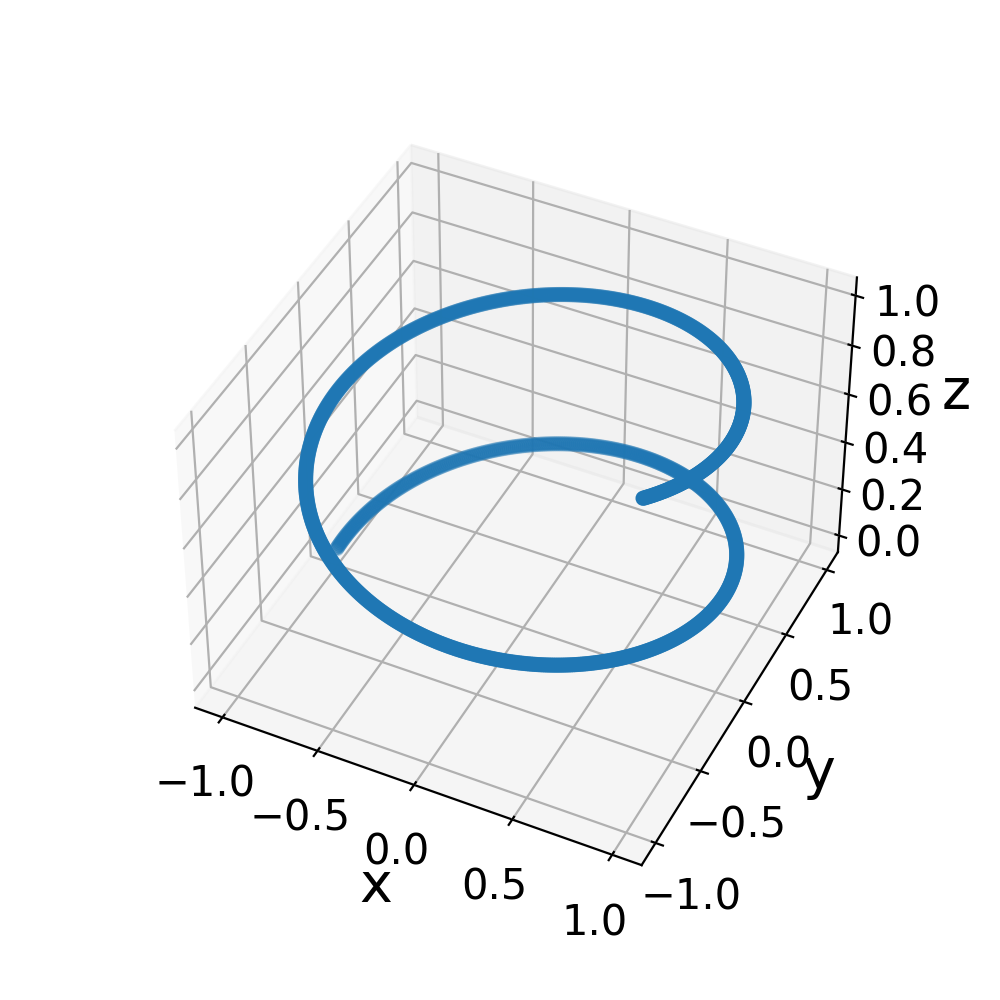

Text(0.5, 0, 'z')

In [378]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pos_uniform[:,0], pos_uniform[:,1], pos_uniform[:,2])

ax.set_xlabel("x"), ax.set_ylabel("y"); ax.set_zlabel("z")
# ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1); ax.set_zlim(-1.1, 1.1)

# Section 2: Particle motion in a static, uniform electric and magnetic field ($E \times B$ drift)

In [308]:
# Run the simulation

steps = 2000   # number of time steps over which to advance the particle
dt = 0.01      # size of a single time step, in arbitrary units

pos_ExB = np.zeros((steps, 3))    # initialize an array to track particle positions
vels_ExB = np.zeros((steps, 3))   # initialize an array to track particle velocities

q = 1.0                                      # particle's charge, in arbitrary units 
m = 1.0                                      # particle's mass, in arbitrary units 
pos_ExB[0] = np.array([0.0, 0.0, 0.0])   # particle's initial position, [x, y, z]  
vels_ExB[0] = np.array([0.0, 0.0, 0.1])  # particle's initial velocity, [vx, vy, vz]  (change this)

E = np.array([0.0, 1.0, 0.0])    # static electric field in y-direction (only change y-component)
B = np.array([0.0, 0.0, 1.0])    # static magnetic field in z-direction (only change z-component)

# trace out the particle's trajectory and save position and velocity at each time step
for i in range(1, steps):
    newpos, newvel = boris_push(pos_ExB[i-1], vels_ExB[i-1], q, m, E, B, dt)
    pos_ExB[i] = newpos
    vels_ExB[i] = newvel

<IPython.core.display.Javascript object>


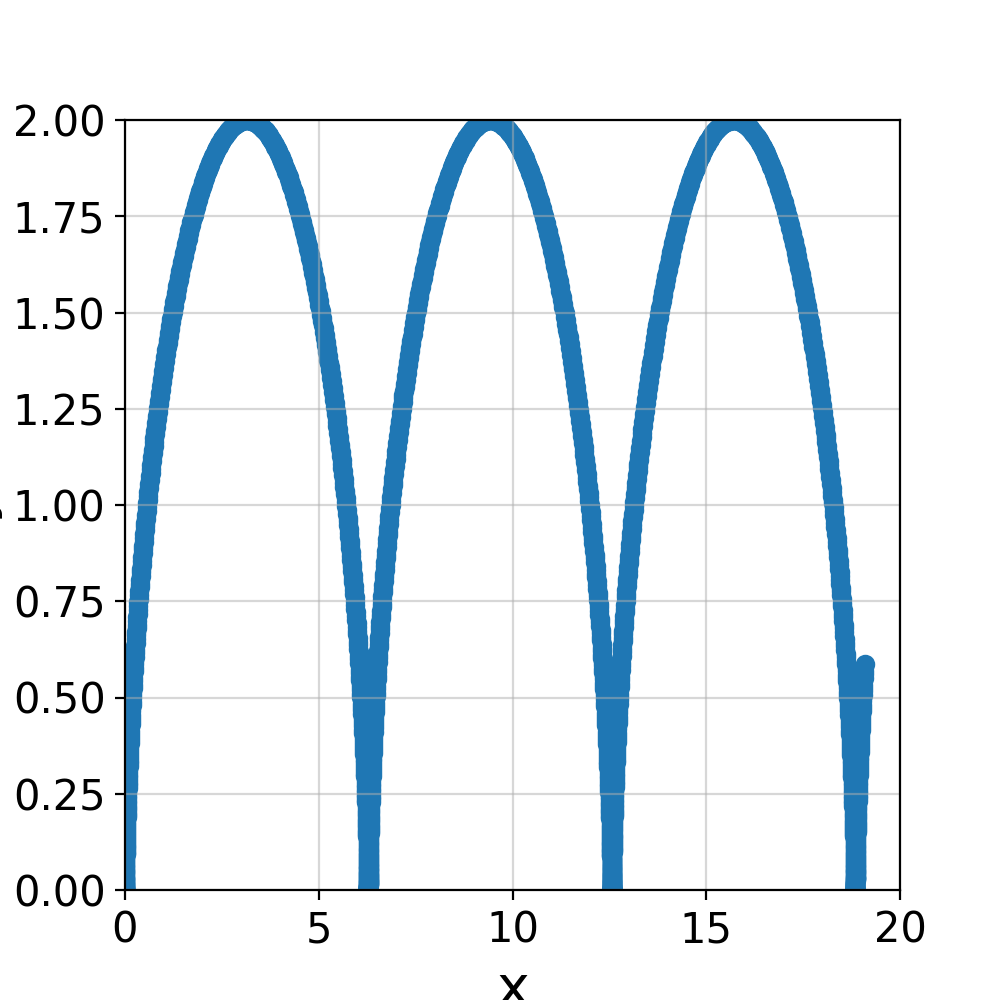

Text(0, 0.5, 'y')

In [304]:
# Plot the trajectory
fig = plt.figure(figsize=(5, 5))    # size of the plot window

plt.scatter(pos_ExB[:,0], pos_ExB[:,1])  # scatter plot of particle positions, y vs. x

plt.xlim(0, 20)  # lower and upper bounds on x (adjust this to change the range of x shown)
plt.ylim(0, 2)  # lower and upper bounds on y (adjust this to change the range of y shown)
plt.xlabel("x"); plt.ylabel("y")

<IPython.core.display.Javascript object>


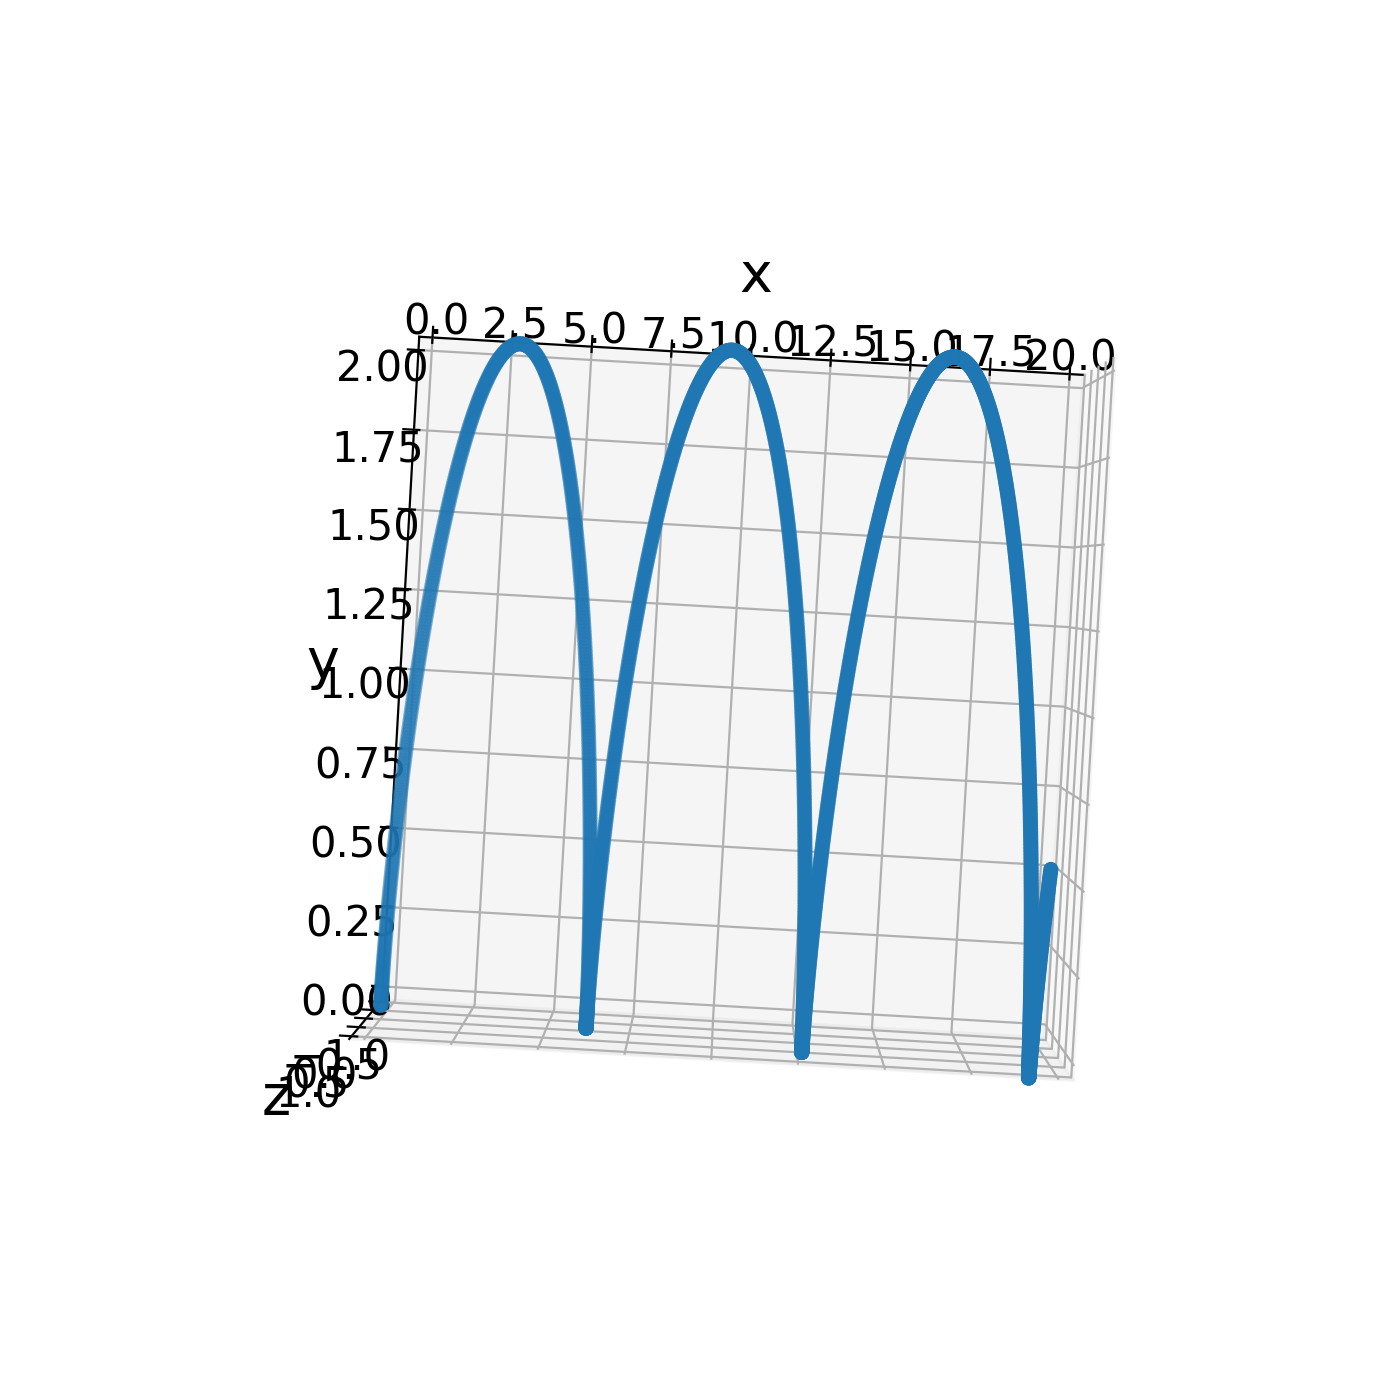

(-1.1, 1.1)

In [311]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pos_ExB[:,0], pos_ExB[:,1], pos_ExB[:,2])

ax.set_xlabel("x"), ax.set_ylabel("y"); ax.set_zlabel("z")
# ax.set_xlim(0, 20); ax.set_ylim(0, 2); ax.set_zlim(-1.1, 1.1)

# Section 3: Particle motion in a static magnetic field with constant gradient ($\nabla B$ drift)

In [313]:
# Define a static magnetic field pointing in the z-direction with gradient in the y-direction;
# the field has magnitude B0 at y=0 and the gradient has constant magnitude B0*alpha. 
# Changing alpha steepens or shallows the gradient (do not modify alpha here).

def B_field_linear(x, y, z, B0=1.0, alpha=0.1):
    
    Bz = B0 * (1.0 + alpha * y)
    
    return np.array([0.0, 0.0, Bz])

In [341]:
# Run the simulation

steps = 6000   # number of time steps over which to advance the particle
dt = 0.01      # size of a single time step, in arbitrary units

pos_gradB = np.zeros((steps, 3))    # initialize an array to track particle positions
vels_gradB = np.zeros((steps, 3))   # initialize an array to track particle velocities
mus = np.zeros(steps)               # initialize an array to track particle magnetic moments

q = 1.0                                      # particle's charge, in arbitrary units 
m = 1.0                                      # particle's mass, in arbitrary units 
pos_gradB[0] = np.array([0.0, 0.0, 0.0])     # particle's initial position, [x, y, z]  
vels_gradB[0] = np.array([1.0, 0.0, 0.0])    # particle's initial velocity, [vx, vy, vz]  
E = np.array([0.0, 0.0, 0.0])    # static electric field, set to 0

B0_sim = 1.0        # set B0 for this simulation
alpha_sim = 0.1    # set alpha for this simulation (change this)

B_init = B_field_linear(*pos_gradB[0], B0=B0_sim, alpha=alpha_sim)              # B-field at initial particle position
mus[0] = 0.5 * m * (vels_gradB[0,0]**2 + vels_gradB[0,1]**2)/np.abs(B_init[2])  # initial magnetic moment


# trace out the particle's trajectory and save position and velocity at each time step
for i in range(1, steps):
    B = B_field_linear(*pos_gradB[i-1], B0=B0_sim, alpha=alpha_sim)
    
    newpos, newvel = boris_push(pos_gradB[i-1], vels_gradB[i-1], q, m, E, B, dt)
    mus[i] = 0.5 * m * (newvel[0]**2 + newvel[1]**2)/np.abs(B[2])
    
    pos_gradB[i] = newpos
    vels_gradB[i] = newvel

<IPython.core.display.Javascript object>


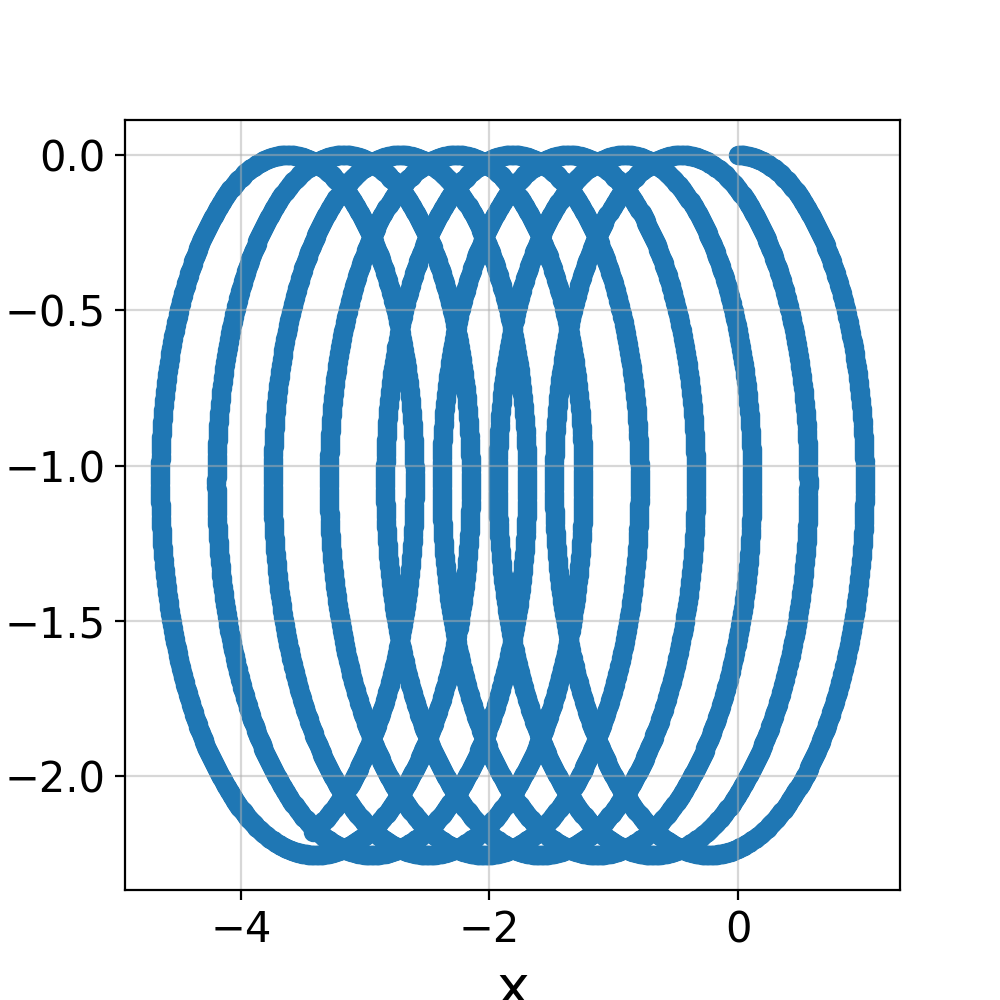

Text(0, 0.5, 'y')

In [342]:
# Plot the trajectory
fig = plt.figure(figsize=(5, 5))    # size of the plot window

plt.scatter(pos_gradB[:,0], pos_gradB[:,1])  # scatter plot of particle positions, y vs. x

# plt.xlim(0, 20)  # lower and upper bounds on x (adjust this to change the range of x shown)
# plt.ylim(0, 2)  # lower and upper bounds on y (adjust this to change the range of y shown)
plt.xlabel("x"); plt.ylabel("y")

<IPython.core.display.Javascript object>


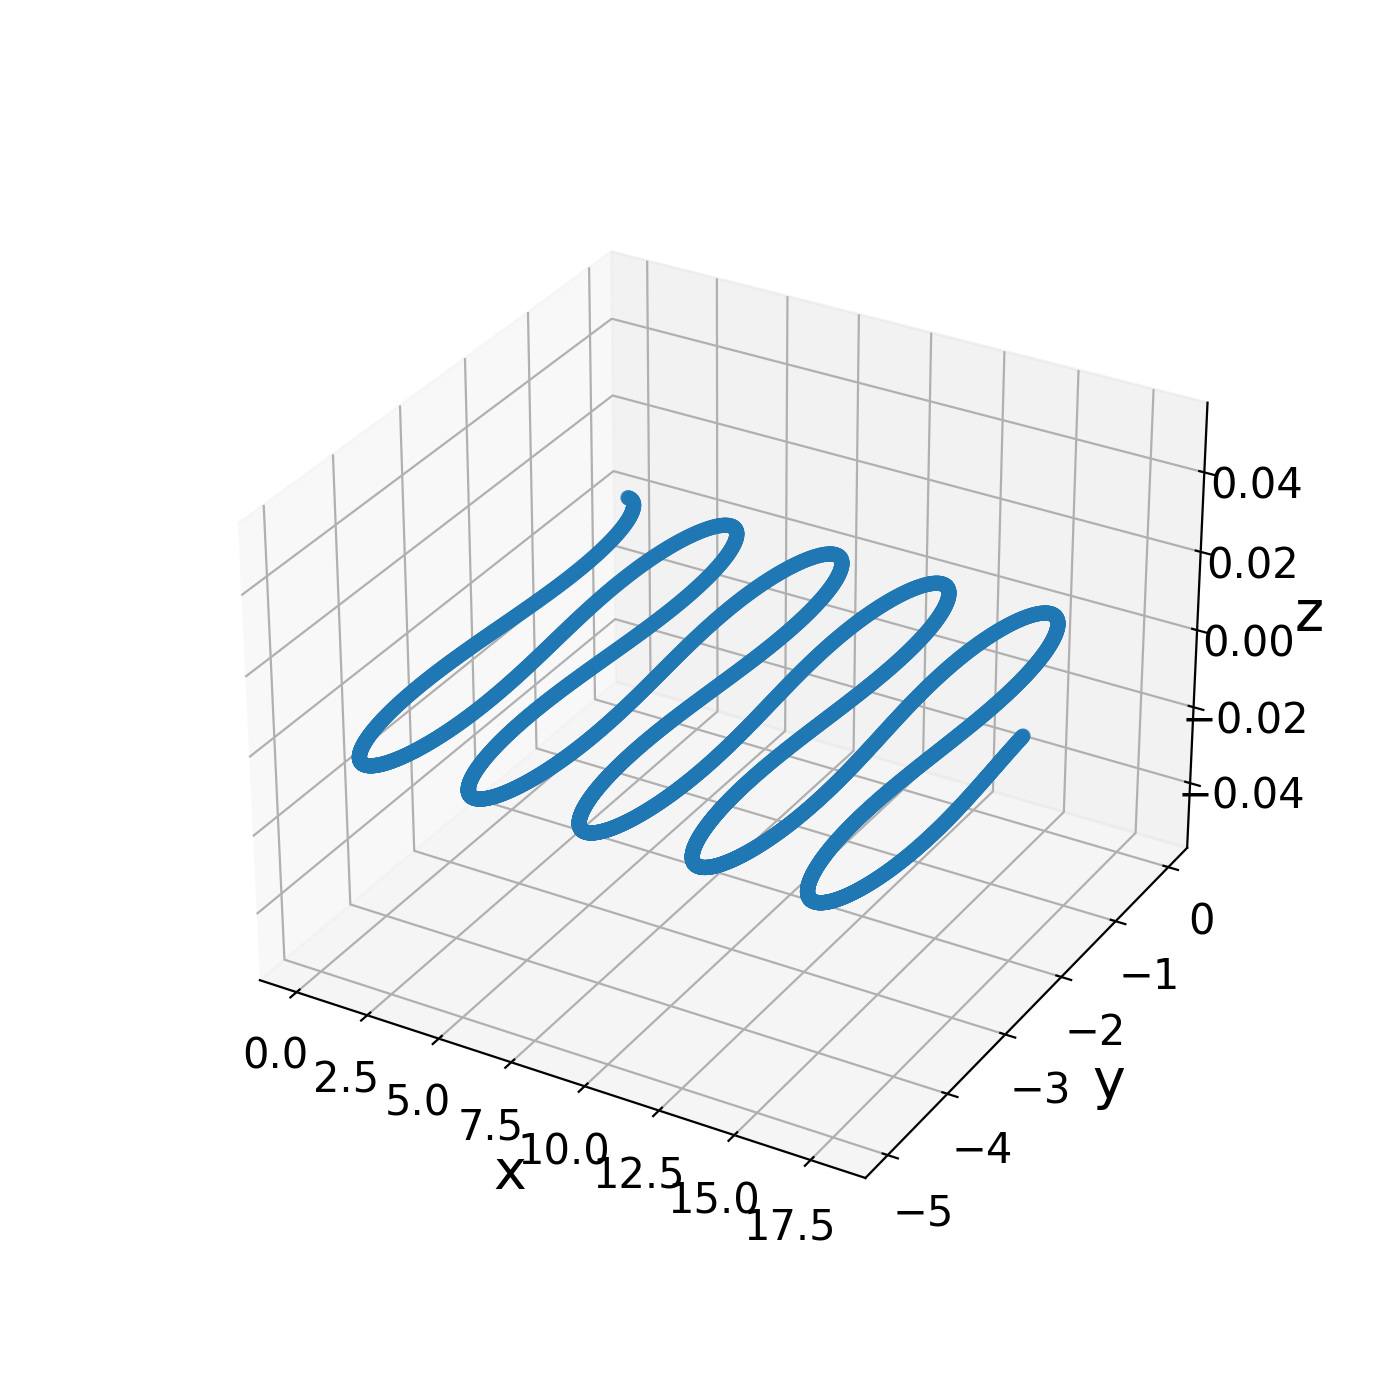

Text(0.5, 0, 'z')

In [337]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pos_gradB[:,0], pos_gradB[:,1], pos_gradB[:,2])

ax.set_xlabel("x"), ax.set_ylabel("y"); ax.set_zlabel("z")
# ax.set_xlim(0, 20); ax.set_ylim(0, 2); ax.set_zlim(-1.1, 1.1)

<IPython.core.display.Javascript object>


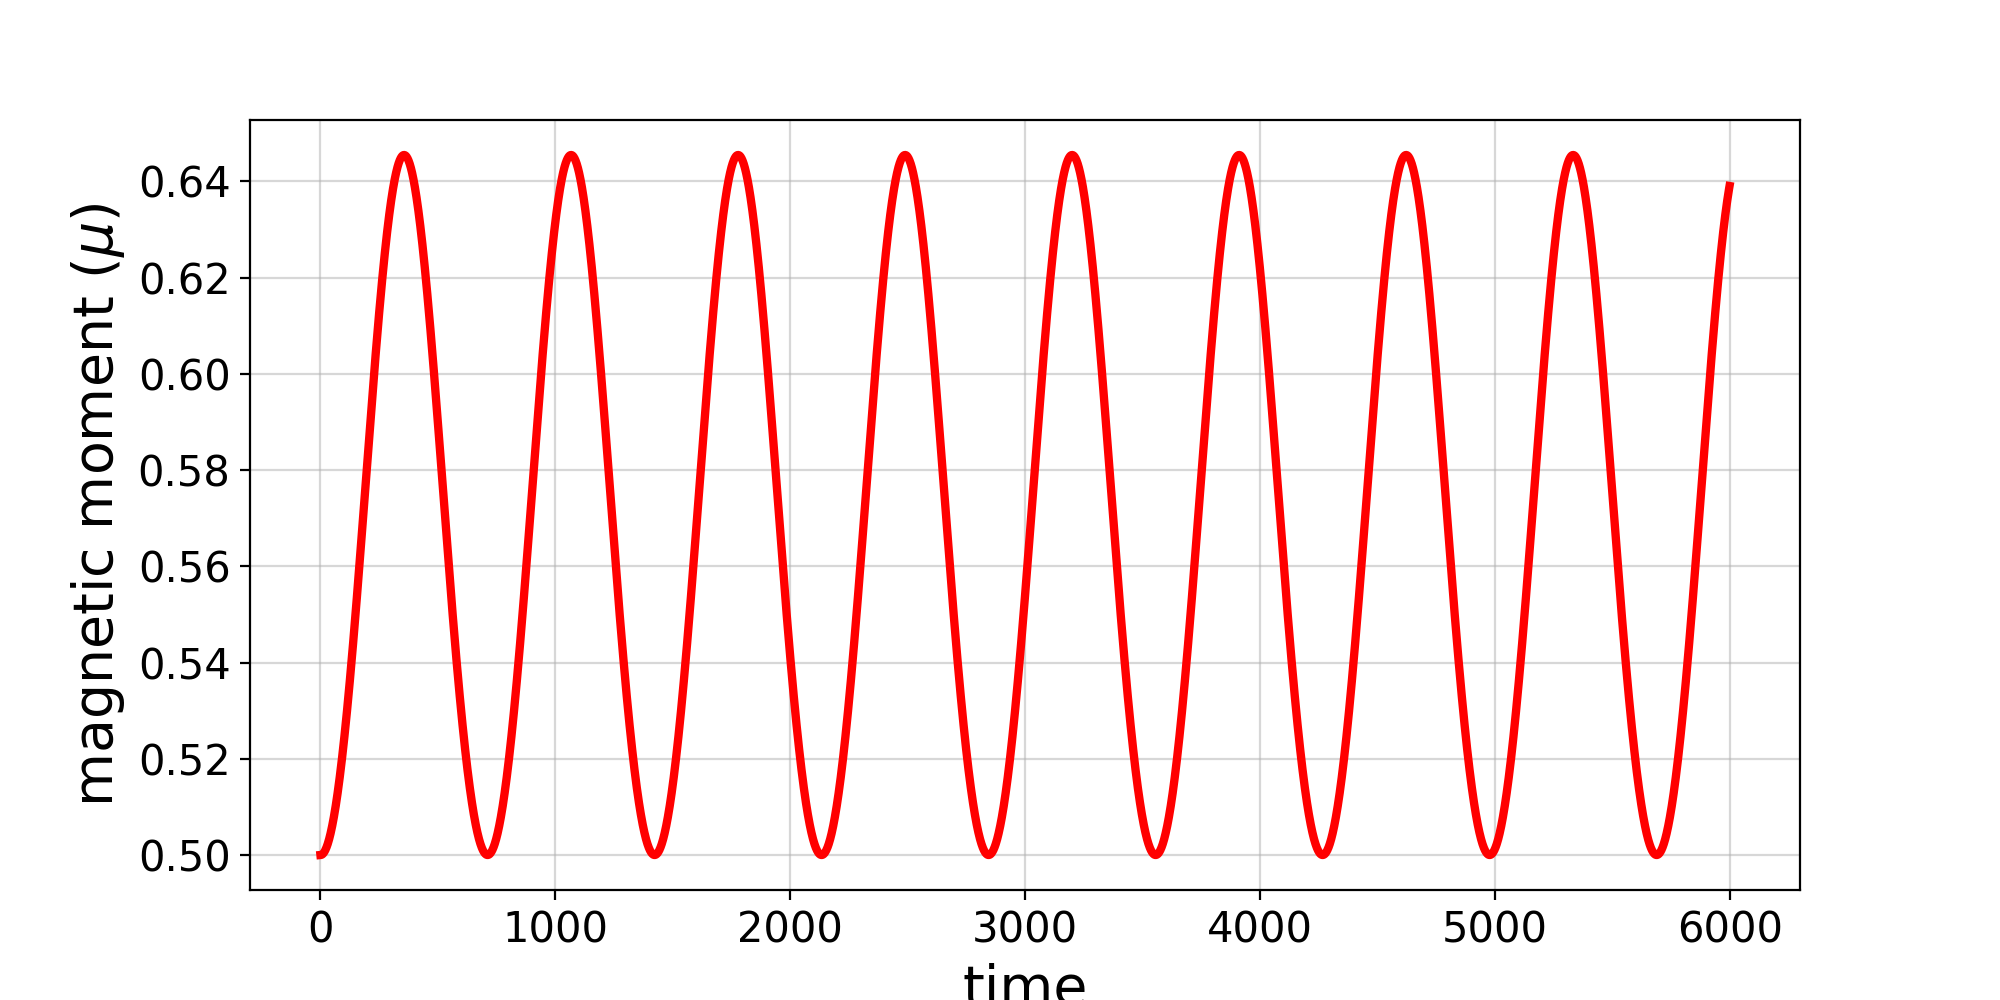

Text(0, 0.5, 'magnetic moment ($\\mu$)')

In [345]:
plt.figure(figsize=(10,5))

plt.plot(range(steps), mus, color='red', linewidth=3)

plt.xlabel("time"); plt.ylabel(r"magnetic moment ($\mu$)")

# plt.xlim(0, 50)
# plt.ylim(1, 60)

# Section 4: Particle motion in a magnetic bottle

In [356]:
# Define a static magnetic field that creates a magnetic bottle in the x-direction (i.e., two magnetic mirrors
# at x ~ +/- L);
# the field has magnitude B0 at y=0 and the gradient has constant magnitude B0*alpha. 
# Changing alpha steepens or shallows the gradient (do not modify alpha here).

def B_mirror(x, y, z, B0=1.0, L=10.0):
    
    # Converging field lines, stronger near x = 0
    Bx = B0 * (1 + (x/L)**2)
    By = -B0 * (2*x/L**2) * y   # ensures div B = 0 (to leading order)
    
    return np.array([Bx, By, 0.0])

In [350]:
# def B_mirror(x, y, B0=1.0, L=10.0):
#     Bx = B0 * (1 + (x/L)**2)
#     By = -B0 * (2*x/L**2) * y
#     return Bx, By

/tmp/ipykernel_143/1779642268.py:12: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array([Bx, By, 0.0])


<IPython.core.display.Javascript object>


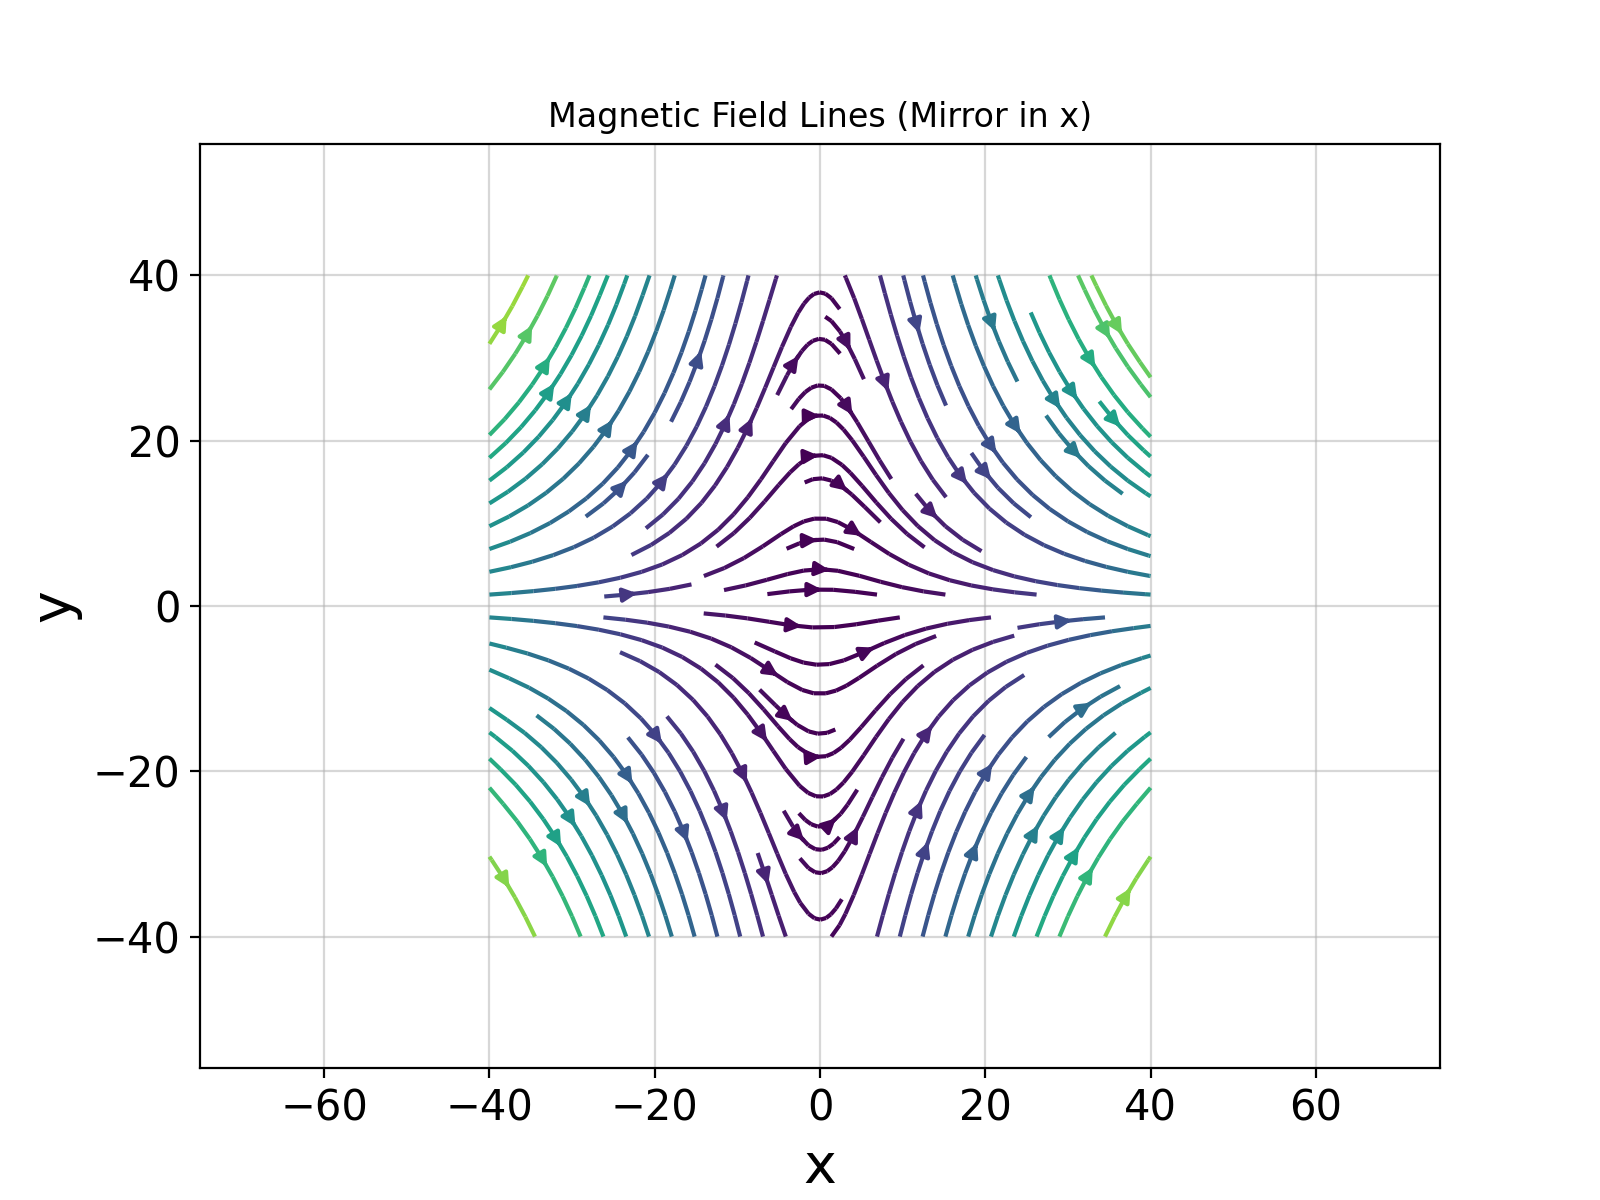

In [359]:
# --- Grid ---
x = np.linspace(-40, 40, 200)
y = np.linspace(-40, 40, 200)
X, Y = np.meshgrid(x, y)

Bx, By, _ = B_mirror(X, Y, 0)

Bmag = np.sqrt(Bx**2 + By**2)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.streamplot(X, Y, Bx, By, color=Bmag, density=1.0)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Magnetic Field Lines (Mirror in x)")
plt.axis("equal")
plt.grid(True)
plt.show()

In [370]:
# Run the simulation

steps = 6000   # number of time steps over which to advance the particle
dt = 0.01      # size of a single time step, in arbitrary units

pos_mirror = np.zeros((steps, 3))    # initialize an array to track particle positions
vels_mirror = np.zeros((steps, 3))   # initialize an array to track particle velocities

q = 1.0                                      # particle's charge, in arbitrary units 
m = 1.0                                      # particle's mass, in arbitrary units 
pos_mirror[0] = np.array([0.0, 0.0, 0.0])     # particle's initial position, [x, y, z]  
vels_mirror[0] = np.array([1.0, 4.0, 0.0])    # particle's initial velocity, [vx, vy, vz]  
E = np.array([0.0, 0.0, 0.0])    # static electric field, set to 0

B0_sim = 1.0        # set B0 for this simulation
L_sim = 10.0        # set L for this simulation (change this)

# trace out the particle's trajectory and save position and velocity at each time step
for i in range(1, steps):
    B = B_mirror(*pos_mirror[i-1], B0=B0_sim, L=L_sim)
    
    newpos, newvel = boris_push(pos_mirror[i-1], vels_mirror[i-1], q, m, E, B, dt)
    
    pos_mirror[i] = newpos
    vels_mirror[i] = newvel

<IPython.core.display.Javascript object>


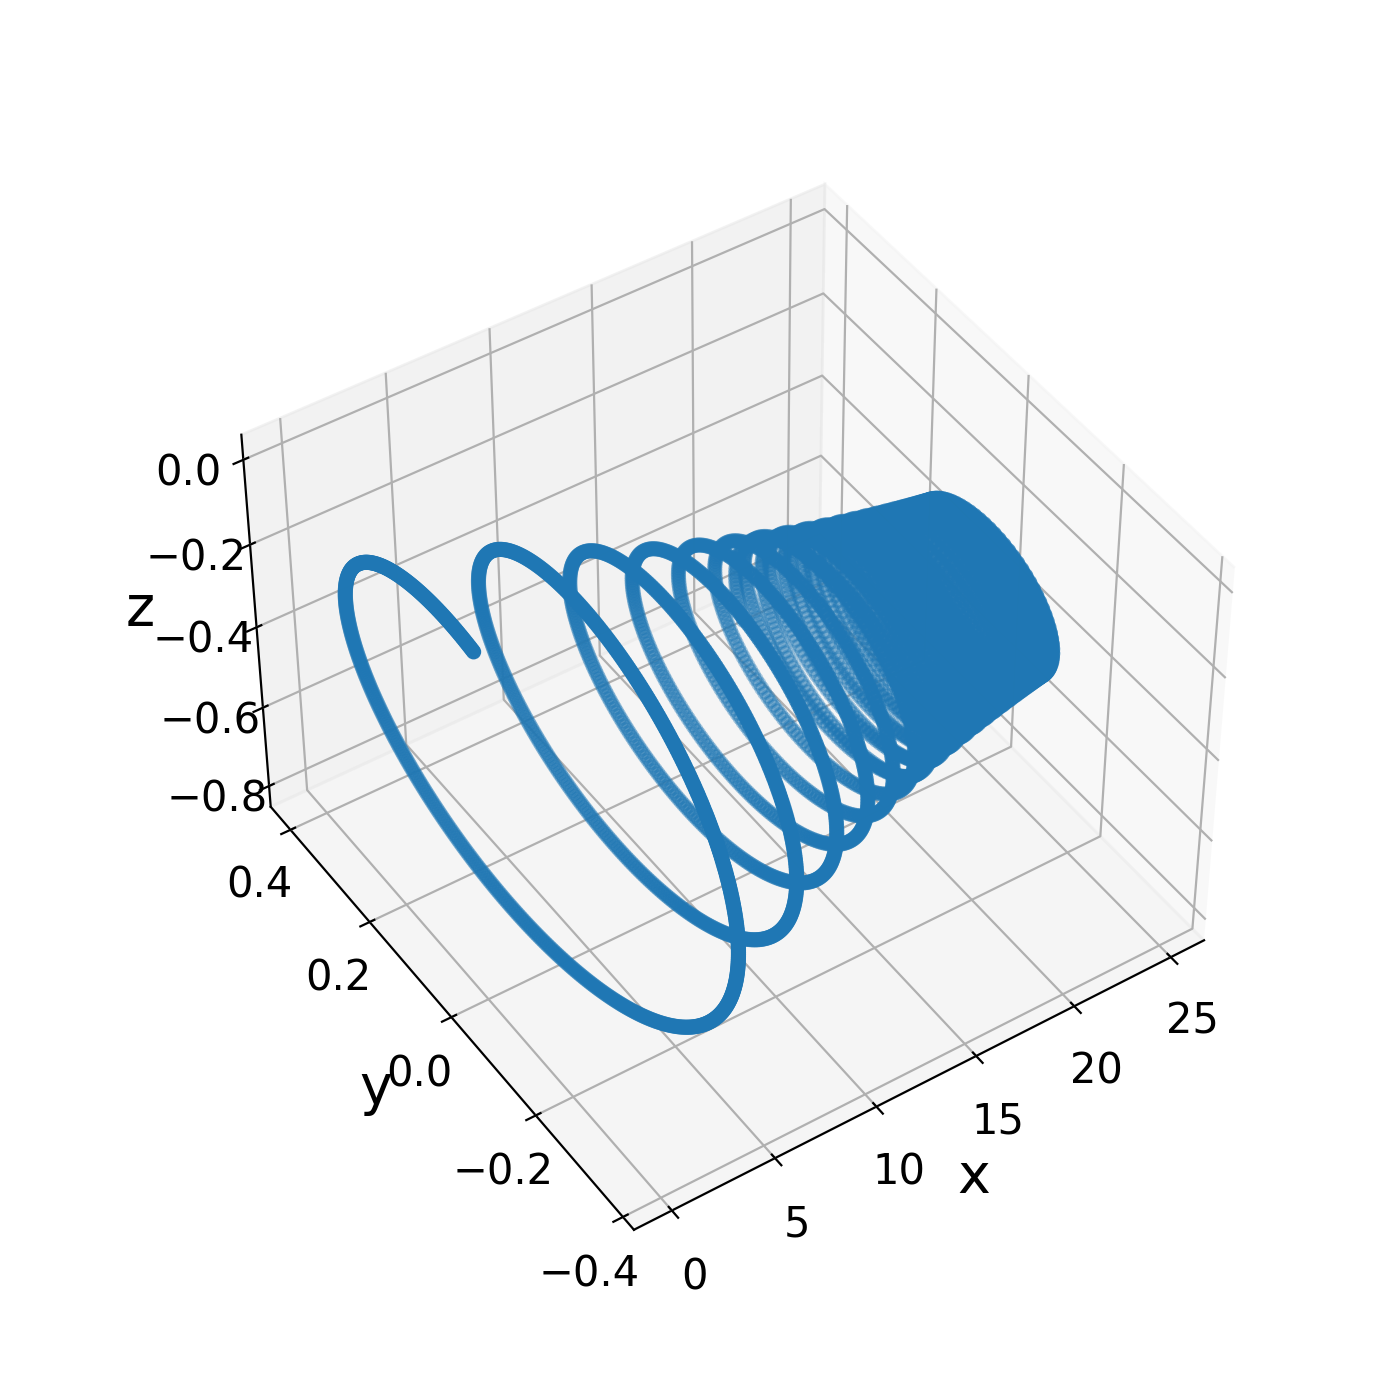

Text(0.5, 0, 'z')

In [368]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pos_mirror[:,0], pos_mirror[:,1], pos_mirror[:,2])

ax.set_xlabel("x"), ax.set_ylabel("y"); ax.set_zlabel("z")
# ax.set_xlim(0, 20); ax.set_ylim(0, 2); ax.set_zlim(-1.1, 1.1)

<IPython.core.display.Javascript object>


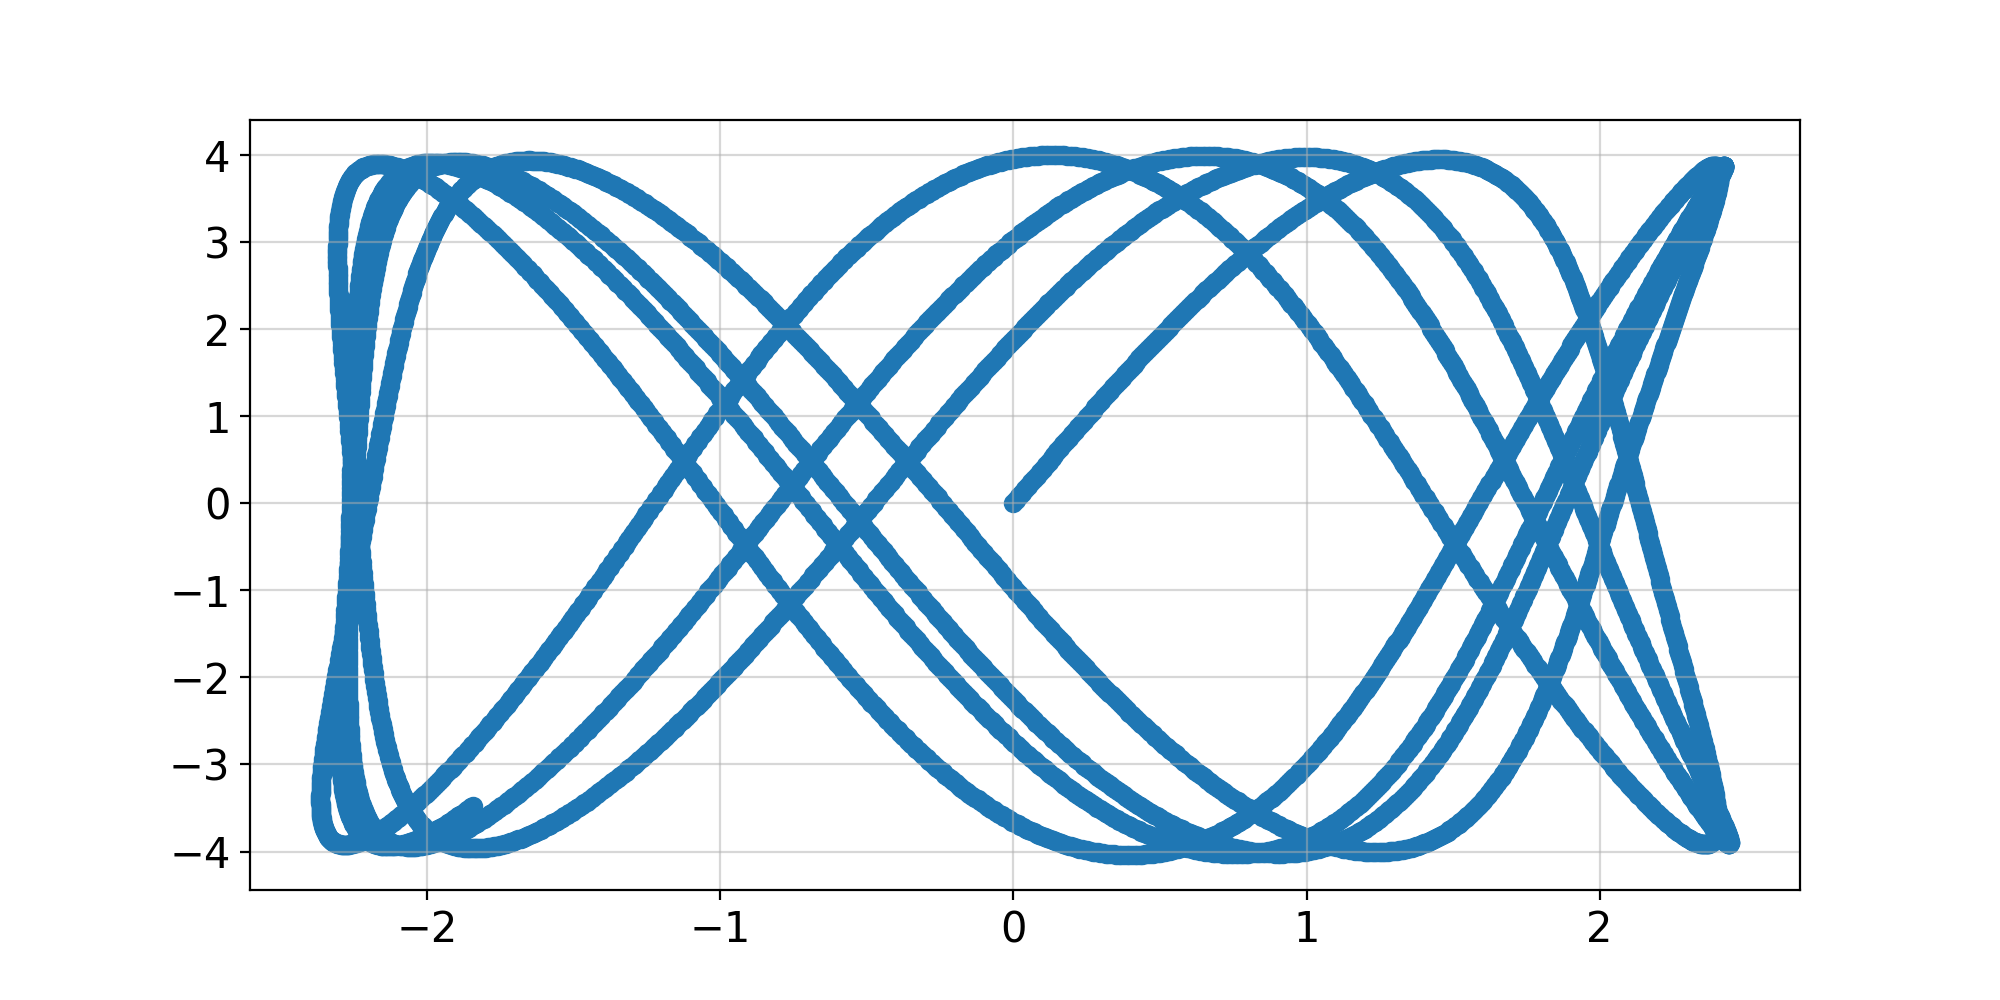

In [372]:
plt.figure(figsize=(10,5))

plt.scatter(pos_mirror[:,0], pos_mirror[:,1])

#plt.xlim(0, 60)
#plt.ylim(0, 10)

In [376]:
plt.ioff()
fig, ax = plt.subplots()

scat = ax.scatter(pos_mirror[0,0], pos_mirror[0,1])
# line2 = ax.plot(t[0], z2[0], label=f'v0 = {v02} m/s')[0]
ax.set(xlim=[-4, 4], ylim=[-5, 5], xlabel='x', ylabel='y')


def update(frame):
    # for each frame, update the data stored on each artist.
    x = pos_mirror[:frame, 0]
    y = pos_mirror[:frame, 1]
    # update the scatter plot:
    data = np.stack([x, y]).T
    scat.set_offsets(data)
    # update the line plot:
#     line2.set_xdata(t[:frame])
#     line2.set_ydata(z2[:frame])
    return scat


ani = animation.FuncAnimation(fig=fig, func=update, frames=range(0,6000,50), interval=100)
HTML(ani.to_jshtml())

plt.ion()